# Analysis: IQ-TREE GPU (OpenACC) vs CPU (VANILA) — +I and +I+G4 Bugfix

**Date:** 2026-03-19  
**Bug fixes applied:**
- **Bug 1:** ptn_invar GPU sync in `computePtnInvar()` (13 lines in phylotreesse.cpp)
- **Bug 2:** Download `_pattern_lh_cat` from GPU after reduction kernel (4 lines in phylokernel_openacc.cpp)

**Expected:** +I and +I+G4 models should now pass. Other models unchanged.


In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

cwd = os.getcwd()
results_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_19_complexdata_bugfixes_I_G"
print(f"Working directory : {cwd}")
print(f"Results directory : {results_path}")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "font.size": 11})

Working directory : /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_19_complexdata_bugfixes_I_G
Results directory : /Users/u7826985/Projects/Nvidia/results/2026_03_19_complexdata_bugfixes_I_G


# 1. Parse all .iqtree and .log files

In [2]:
# Patterns for .iqtree files
iqtree_ll_pattern = re.compile(r'Log-likelihood of the tree:\s+([-\d.]+)')
iqtree_rate_params = re.compile(r'Rate parameter R:')
iqtree_freerate_pattern = re.compile(r'Site proportion and rates:\s+(.+)')
iqtree_gamma_shape = re.compile(r'Gamma shape alpha:\s+([\d.]+)')
iqtree_pinvar = re.compile(r'Proportion of invariable sites:\s+([\d.]+)')

# Patterns for .log files
log_alignment_pattern = re.compile(r'Alignment has (\d+) sequences with (\d+) columns, (\d+) distinct patterns')
log_initial_ll = re.compile(r'Initial log-likelihood:\s+([-\d.]+)')
log_optimal_ll = re.compile(r'Optimal log-likelihood:\s+([-\d.]+)')
log_params_opt = re.compile(r'Parameters optimization took (\d+) rounds? \(([\d.]+) sec\)')
log_wallclock = re.compile(r'Total wall-clock time used:\s+([\d.]+)\s+sec')
log_underflow_deriv = re.compile(r'WARNING: Numerical underflow for OpenACC lh-derivative')
log_underflow_sites = re.compile(r'WARNING: Numerical underflow caused by alignment sites')
log_best_score = re.compile(r'BEST SCORE FOUND\s*:\s*([-\d.]+)')

In [3]:
def parse_iqtree_file(filepath):
    """Parse .iqtree file for final log-likelihood and model parameters."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    result = {}
    
    # Final log-likelihood
    m = iqtree_ll_pattern.search(content)
    result['final_ll'] = float(m.group(1)) if m else np.nan
    
    # FreeRate site proportions and rates
    m = iqtree_freerate_pattern.search(content)
    if m:
        result['site_rates_str'] = m.group(1).strip()
        # Parse (prop, rate) pairs
        pairs = re.findall(r'\(([^)]+)\)', m.group(1))
        props = []
        rates = []
        has_nan = False
        for pair in pairs:
            parts = pair.split(',')
            if len(parts) == 2:
                try:
                    p, r = float(parts[0]), float(parts[1])
                    props.append(p)
                    rates.append(r)
                except ValueError:
                    has_nan = True
                    props.append(np.nan)
                    rates.append(np.nan)
        result['freerate_props'] = props
        result['freerate_rates'] = rates
        result['has_nan_rates'] = has_nan or any(np.isnan(r) for r in rates)
    else:
        result['site_rates_str'] = None
        result['freerate_props'] = []
        result['freerate_rates'] = []
        result['has_nan_rates'] = False
    
    # Gamma shape
    m = iqtree_gamma_shape.search(content)
    result['gamma_shape'] = float(m.group(1)) if m else np.nan
    
    # Proportion of invariable sites
    m = iqtree_pinvar.search(content)
    result['pinvar'] = float(m.group(1)) if m else np.nan
    
    return result


def parse_log_file(filepath):
    """Parse .log file for timing, likelihood progression, and warnings."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    result = {}
    
    # Alignment info
    m = log_alignment_pattern.search(content)
    if m:
        result['taxa'] = int(m.group(1))
        result['sites'] = int(m.group(2))
        result['patterns'] = int(m.group(3))
    
    # Initial LL
    m = log_initial_ll.search(content)
    result['initial_ll'] = float(m.group(1)) if m else np.nan
    
    # Optimal LL
    m = log_optimal_ll.search(content)
    result['optimal_ll'] = float(m.group(1)) if m else np.nan
    
    # Best score
    m = log_best_score.search(content)
    result['best_score'] = float(m.group(1)) if m else np.nan
    
    # Parameters optimization
    m = log_params_opt.search(content)
    if m:
        result['opt_rounds'] = int(m.group(1))
        result['opt_time'] = float(m.group(2))
    else:
        result['opt_rounds'] = np.nan
        result['opt_time'] = np.nan
    
    # Wall-clock time
    m = log_wallclock.search(content)
    result['wallclock_time'] = float(m.group(1)) if m else np.nan
    
    # Underflow warnings
    result['n_underflow_deriv'] = len(log_underflow_deriv.findall(content))
    result['n_underflow_sites'] = len(log_underflow_sites.findall(content))
    result['has_underflow'] = result['n_underflow_deriv'] > 0 or result['n_underflow_sites'] > 0
    
    return result

In [4]:
def parse_all_results(results_path):
    """Parse all results from the directory structure."""
    rows = []
    
    for data_type in ['AA', 'DNA']:
        data_dir = os.path.join(results_path, data_type)
        if not os.path.exists(data_dir):
            continue
        
        for tree_type in ['rooted', 'unrooted']:
            tree_type_dir = os.path.join(data_dir, tree_type)
            if not os.path.exists(tree_type_dir):
                continue
            
            for model in sorted(os.listdir(tree_type_dir)):
                model_dir = os.path.join(tree_type_dir, model)
                if not os.path.isdir(model_dir):
                    continue
                
                for tree_folder in sorted(os.listdir(model_dir)):
                    tree_dir = os.path.join(model_dir, tree_folder)
                    if not os.path.isdir(tree_dir):
                        continue
                    
                    tree_num = int(re.search(r'(\d+)', tree_folder).group(1))
                    
                    # Find VANILA and OPENACC log+iqtree files
                    files = os.listdir(tree_dir)
                    for backend_key, backend_name in [('VANILA', 'VANILA'), ('OPENACC', 'OPENACC')]:
                        log_files = [f for f in files if f.endswith('.log') and backend_key in f]
                        iqtree_files = [f for f in files if f.endswith('.iqtree') and backend_key in f]
                        
                        if not log_files or not iqtree_files:
                            continue
                        
                        log_path = os.path.join(tree_dir, log_files[0])
                        iqtree_path = os.path.join(tree_dir, iqtree_files[0])
                        
                        log_data = parse_log_file(log_path)
                        iqtree_data = parse_iqtree_file(iqtree_path)
                        
                        row = {
                            'data_type': data_type,
                            'tree_type': tree_type,
                            'model': model,
                            'tree_num': tree_num,
                            'tree_folder': tree_folder,
                            'backend': backend_name,
                            **log_data,
                            **iqtree_data,
                        }
                        rows.append(row)
    
    df = pd.DataFrame(rows)
    return df

df = parse_all_results(results_path)
print(f"Total records parsed: {len(df)}")
print(f"\nRecords per data_type x tree_type x model x backend:")
summary = df.groupby(['data_type', 'tree_type', 'model', 'backend']).size().unstack(fill_value=0)
display(summary)

Total records parsed: 440

Records per data_type x tree_type x model x backend:


backend                       OPENACC  VANILA
data_type tree_type model                    
AA        rooted    LG             10      10
                    LG+C60         10      10
                    LG+G4          10      10
                    LG+I           10      10
                    LG+I+G4        10      10
                    LG+R4          10      10
          unrooted  LG             10      10
                    LG+C60         10      10
                    LG+G4          10      10
                    LG+I           10      10
                    LG+I+G4        10      10
                    LG+R4          10      10
DNA       rooted    GTR            10      10
                    GTR+G4         10      10
                    GTR+I          10      10
                    GTR+I+G4       10      10
                    GTR+R4         10      10
          unrooted  GTR            10      10
                    GTR+G4         10      10
                    GTR+I          10      10
                    GTR+I+G4       10      10
                    GTR+R4         10      10

# 2. Numerical Correctness: Log-Likelihood Comparison (OpenACC vs VANILA)

In [5]:
# Pivot: for each (data_type, tree_type, model, tree_num), compare VANILA vs OPENACC final_ll
merge_keys = ['data_type', 'tree_type', 'model', 'tree_num']

vanila = df[df['backend'] == 'VANILA'][merge_keys + ['final_ll', 'optimal_ll', 'best_score', 'opt_rounds', 'opt_time', 'wallclock_time']].copy()
openacc = df[df['backend'] == 'OPENACC'][merge_keys + ['final_ll', 'optimal_ll', 'best_score', 'opt_rounds', 'opt_time', 'wallclock_time', 
             'has_underflow', 'n_underflow_deriv', 'n_underflow_sites', 'has_nan_rates']].copy()

vanila = vanila.rename(columns={c: f'{c}_vanila' for c in vanila.columns if c not in merge_keys})
openacc = openacc.rename(columns={c: f'{c}_openacc' for c in openacc.columns if c not in merge_keys})

merged = vanila.merge(openacc, on=merge_keys, how='outer', indicator=True)

print("Merge status:")
print(merged['_merge'].value_counts())
print(f"\nTotal matched pairs (both backends): {(merged['_merge'] == 'both').sum()}")
print(f"VANILA only: {(merged['_merge'] == 'left_only').sum()}")
print(f"OPENACC only: {(merged['_merge'] == 'right_only').sum()}")

Merge status:
_merge
both          220
left_only       0
right_only      0
Name: count, dtype: int64

Total matched pairs (both backends): 220
VANILA only: 0
OPENACC only: 0


In [6]:
# Compute LL differences for matched pairs
both = merged[merged['_merge'] == 'both'].copy()
both['ll_diff'] = both['final_ll_openacc'] - both['final_ll_vanila']
both['ll_abs_diff'] = both['ll_diff'].abs()
both['ll_match'] = both['ll_abs_diff'] < 0.01  # within 0.01 logL units

print("=" * 90)
print("LOG-LIKELIHOOD DIFFERENCE: OpenACC vs VANILA (final_ll from .iqtree)")
print("=" * 90)

ll_summary = both.groupby(['data_type', 'tree_type', 'model']).agg(
    n_pairs=('ll_diff', 'count'),
    mean_diff=('ll_diff', 'mean'),
    max_abs_diff=('ll_abs_diff', 'max'),
    min_diff=('ll_diff', 'min'),
    max_diff=('ll_diff', 'max'),
    n_match=('ll_match', 'sum'),
    pct_match=('ll_match', 'mean'),
    n_underflow=('has_underflow_openacc', 'sum'),
    n_nan_rates=('has_nan_rates_openacc', 'sum'),
).round(6)
ll_summary['pct_match'] = (ll_summary['pct_match'] * 100).round(1)

display(ll_summary)

LOG-LIKELIHOOD DIFFERENCE: OpenACC vs VANILA (final_ll from .iqtree)


n_pairs  mean_diff  max_abs_diff  min_diff  \
data_type tree_type model                                                  
AA        rooted    LG             10    0.00000        0.0000    0.0000   
                    LG+C60         10  -38.26702       53.4593  -53.4593   
                    LG+G4          10    0.00000        0.0000    0.0000   
                    LG+I           10    0.00000        0.0000    0.0000   
                    LG+I+G4        10    0.00000        0.0000    0.0000   
                    LG+R4          10   -0.25120        1.5164   -1.5164   
          unrooted  LG             10    0.00000        0.0000    0.0000   
                    LG+C60         10  -34.28494       48.5595  -48.5595   
                    LG+G4          10    0.00000        0.0000    0.0000   
                    LG+I           10    0.00000        0.0000    0.0000   
                    LG+I+G4        10    0.00000        0.0000    0.0000   
                    LG+R4          10   -0.67094        1.7632   -1.7632   
DNA       rooted    GTR            10    0.00007        0.0012   -0.0003   
                    GTR+G4         10    0.00000        0.0001   -0.0001   
                    GTR+I          10   -0.00035        0.0028   -0.0028   
                    GTR+I+G4       10    0.00429        0.0405   -0.0015   
                    GTR+R4         10   -0.24612        1.4024   -1.4024   
          unrooted  GTR            10    0.00036        0.0039   -0.0006   
                    GTR+G4         10    0.00001        0.0001    0.0000   
                    GTR+I          10    0.00000        0.0000    0.0000   
                    GTR+I+G4       10   -0.00020        0.0015   -0.0015   
                    GTR+R4         10   -0.53051        3.8257   -3.8257   

                              max_diff  n_match  pct_match  n_underflow  \
data_type tree_type model                                                 
AA        rooted    LG          0.0000       10      100.0            0   
                    LG+C60    -25.5613        0        0.0            0   
                    LG+G4       0.0000       10      100.0            0   
                    LG+I        0.0000       10      100.0            0   
                    LG+I+G4     0.0000       10      100.0            0   
                    LG+R4       0.0152        3       30.0            0   
          unrooted  LG          0.0000       10      100.0            0   
                    LG+C60    -10.4848        0        0.0            0   
                    LG+G4       0.0000       10      100.0            0   
                    LG+I        0.0000       10      100.0            0   
                    LG+I+G4     0.0000       10      100.0            0   
                    LG+R4       0.0105        1       10.0            0   
DNA       rooted    GTR         0.0012       10      100.0            0   
                    GTR+G4      0.0001       10      100.0            0   
                    GTR+I       0.0003       10      100.0            0   
                    GTR+I+G4    0.0405        9       90.0            0   
                    GTR+R4      0.3236        4       40.0            0   
          unrooted  GTR         0.0039       10      100.0            0   
                    GTR+G4      0.0001       10      100.0            0   
                    GTR+I       0.0000       10      100.0            0   
                    GTR+I+G4    0.0001       10      100.0            0   
                    GTR+R4      0.0079        5       50.0            0   

                              n_nan_rates  
data_type tree_type model                  
AA        rooted    LG                  0  
                    LG+C60              0  
                    LG+G4               0  
                    LG+I                0  
                    LG+I+G4             0  
                    LG+R4               0  
          unrooted  LG                  0  
        

In [7]:
# Detailed view: separate CORRECT models vs BROKEN models
print("\n" + "=" * 90)
print("CORRECT MODELS (all trees match within 0.01 logL, no underflow)")
print("=" * 90)
correct_models = ll_summary[(ll_summary['max_abs_diff'] < 0.01) & (ll_summary['n_underflow'] == 0)]
display(correct_models[['n_pairs', 'mean_diff', 'max_abs_diff']])

print("\n" + "=" * 90)
print("MODELS WITH ISSUES (LL mismatch > 0.01 OR underflow warnings)")
print("=" * 90)
problem_models = ll_summary[(ll_summary['max_abs_diff'] >= 0.01) | (ll_summary['n_underflow'] > 0)]
display(problem_models)


CORRECT MODELS (all trees match within 0.01 logL, no underflow)


n_pairs  mean_diff  max_abs_diff
data_type tree_type model                                     
AA        rooted    LG             10    0.00000        0.0000
                    LG+G4          10    0.00000        0.0000
                    LG+I           10    0.00000        0.0000
                    LG+I+G4        10    0.00000        0.0000
          unrooted  LG             10    0.00000        0.0000
                    LG+G4          10    0.00000        0.0000
                    LG+I           10    0.00000        0.0000
                    LG+I+G4        10    0.00000        0.0000
DNA       rooted    GTR            10    0.00007        0.0012
                    GTR+G4         10    0.00000        0.0001
                    GTR+I          10   -0.00035        0.0028
          unrooted  GTR            10    0.00036        0.0039
                    GTR+G4         10    0.00001        0.0001
                    GTR+I          10    0.00000        0.0000
                    GTR+I+G4       10   -0.00020        0.0015


MODELS WITH ISSUES (LL mismatch > 0.01 OR underflow warnings)


n_pairs  mean_diff  max_abs_diff  min_diff  \
data_type tree_type model                                                  
AA        rooted    LG+C60         10  -38.26702       53.4593  -53.4593   
                    LG+R4          10   -0.25120        1.5164   -1.5164   
          unrooted  LG+C60         10  -34.28494       48.5595  -48.5595   
                    LG+R4          10   -0.67094        1.7632   -1.7632   
DNA       rooted    GTR+I+G4       10    0.00429        0.0405   -0.0015   
                    GTR+R4         10   -0.24612        1.4024   -1.4024   
          unrooted  GTR+R4         10   -0.53051        3.8257   -3.8257   

                              max_diff  n_match  pct_match  n_underflow  \
data_type tree_type model                                                 
AA        rooted    LG+C60    -25.5613        0        0.0            0   
                    LG+R4       0.0152        3       30.0            0   
          unrooted  LG+C60    -10.4848        0        0.0            0   
                    LG+R4       0.0105        1       10.0            0   
DNA       rooted    GTR+I+G4    0.0405        9       90.0            0   
                    GTR+R4      0.3236        4       40.0            0   
          unrooted  GTR+R4      0.0079        5       50.0            0   

                              n_nan_rates  
data_type tree_type model                  
AA        rooted    LG+C60              0  
                    LG+R4               0  
          unrooted  LG+C60              0  
                    LG+R4               0  
DNA       rooted    GTR+I+G4            0  
                    GTR+R4              0  
          unrooted  GTR+R4              0

# 3. Underflow Analysis

In [8]:
# Which models/backends have underflow?
underflow_df = df[df['has_underflow'] == True].copy()

print(f"Total runs with underflow warnings: {len(underflow_df)}")
print(f"\nBreakdown by backend:")
print(underflow_df['backend'].value_counts())

print(f"\nBreakdown by model:")
uf_summary = underflow_df.groupby(['data_type', 'tree_type', 'model', 'backend']).agg(
    n_runs=('has_underflow', 'count'),
    mean_deriv_warnings=('n_underflow_deriv', 'mean'),
    max_deriv_warnings=('n_underflow_deriv', 'max'),
    n_site_warnings=('n_underflow_sites', 'sum'),
    n_nan_rates=('has_nan_rates', 'sum'),
).round(1)
display(uf_summary)

Total runs with underflow warnings: 0

Breakdown by backend:
Series([], Name: count, dtype: int64)

Breakdown by model:


,,,,n_runs,mean_deriv_warnings,max_deriv_warnings,n_site_warnings,n_nan_rates
data_type,tree_type,model,backend,,,,,


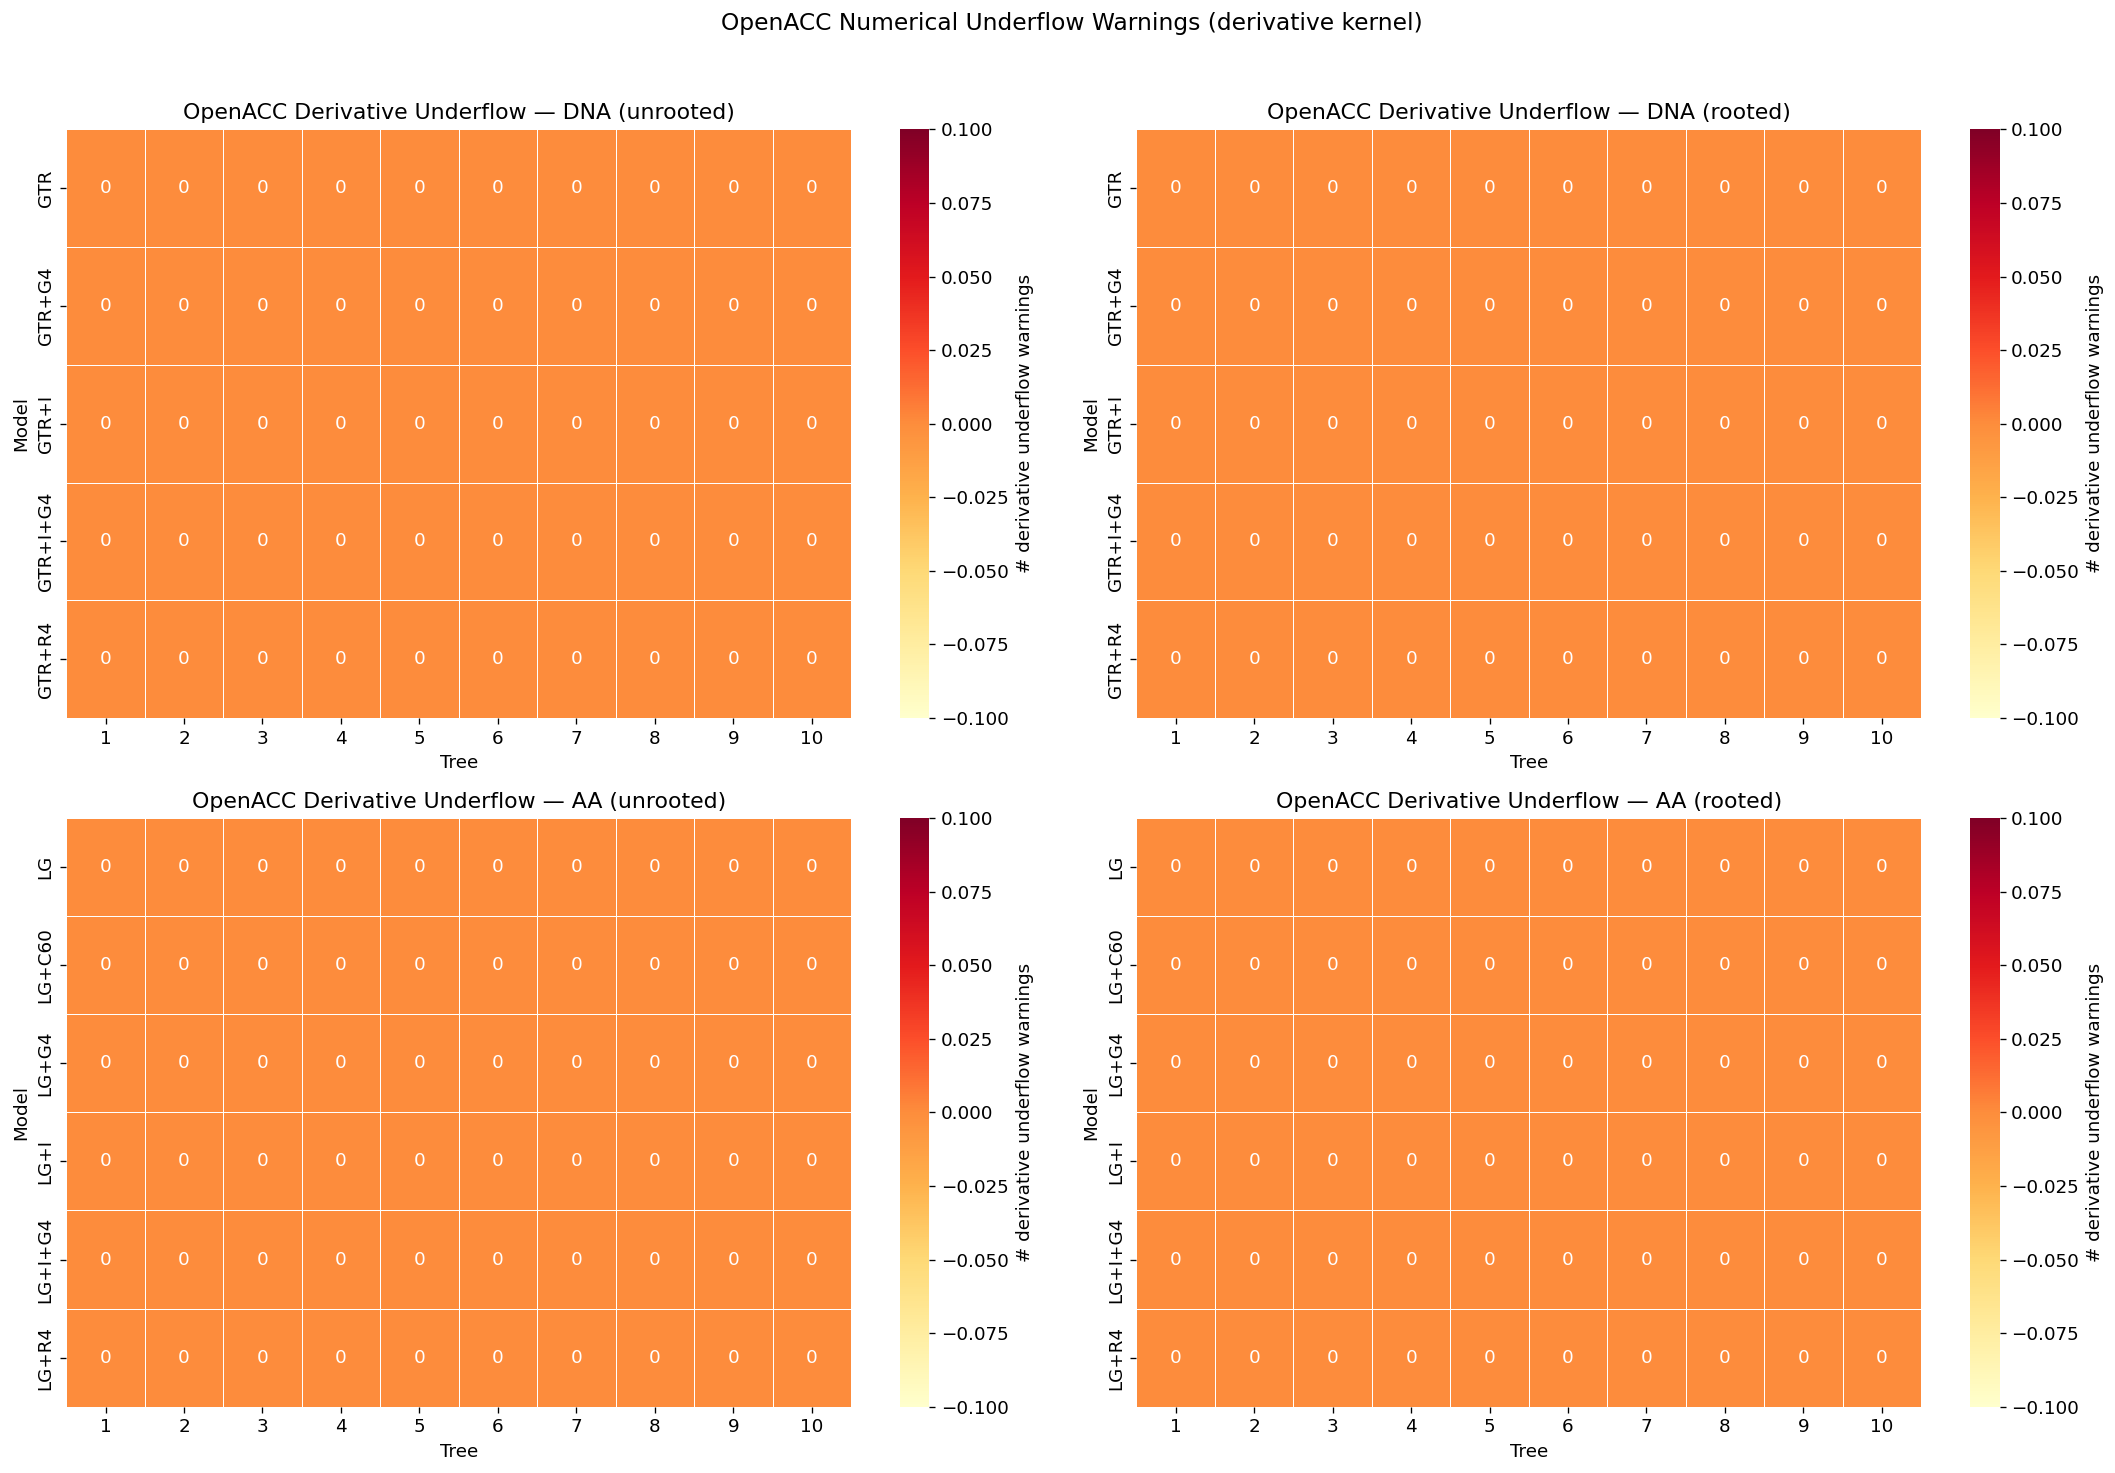

In [9]:
# Heatmap: underflow warning count per model per tree
openacc_df = df[df['backend'] == 'OPENACC'].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
combos = [
    ('DNA', 'unrooted', axes[0, 0]),
    ('DNA', 'rooted',   axes[0, 1]),
    ('AA',  'unrooted', axes[1, 0]),
    ('AA',  'rooted',   axes[1, 1]),
]

for data_type, tree_type, ax in combos:
    subset = openacc_df[(openacc_df['data_type'] == data_type) & 
                        (openacc_df['tree_type'] == tree_type)]
    if len(subset) == 0:
        ax.set_title(f'{data_type} ({tree_type}) — No data')
        ax.axis('off')
        continue
    
    pivot = subset.pivot_table(index='model', columns='tree_num', 
                                values='n_underflow_deriv', aggfunc='sum', fill_value=0)
    pivot = pivot[sorted(pivot.columns)].astype(int)
    
    sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5,
                cbar_kws={'label': '# derivative underflow warnings'})
    ax.set_title(f'OpenACC Derivative Underflow — {data_type} ({tree_type})')
    ax.set_xlabel('Tree')
    ax.set_ylabel('Model')

plt.suptitle('OpenACC Numerical Underflow Warnings (derivative kernel)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/underflow_heatmap.png', bbox_inches='tight')
plt.show()

# 4. Log-Likelihood Difference Heatmaps

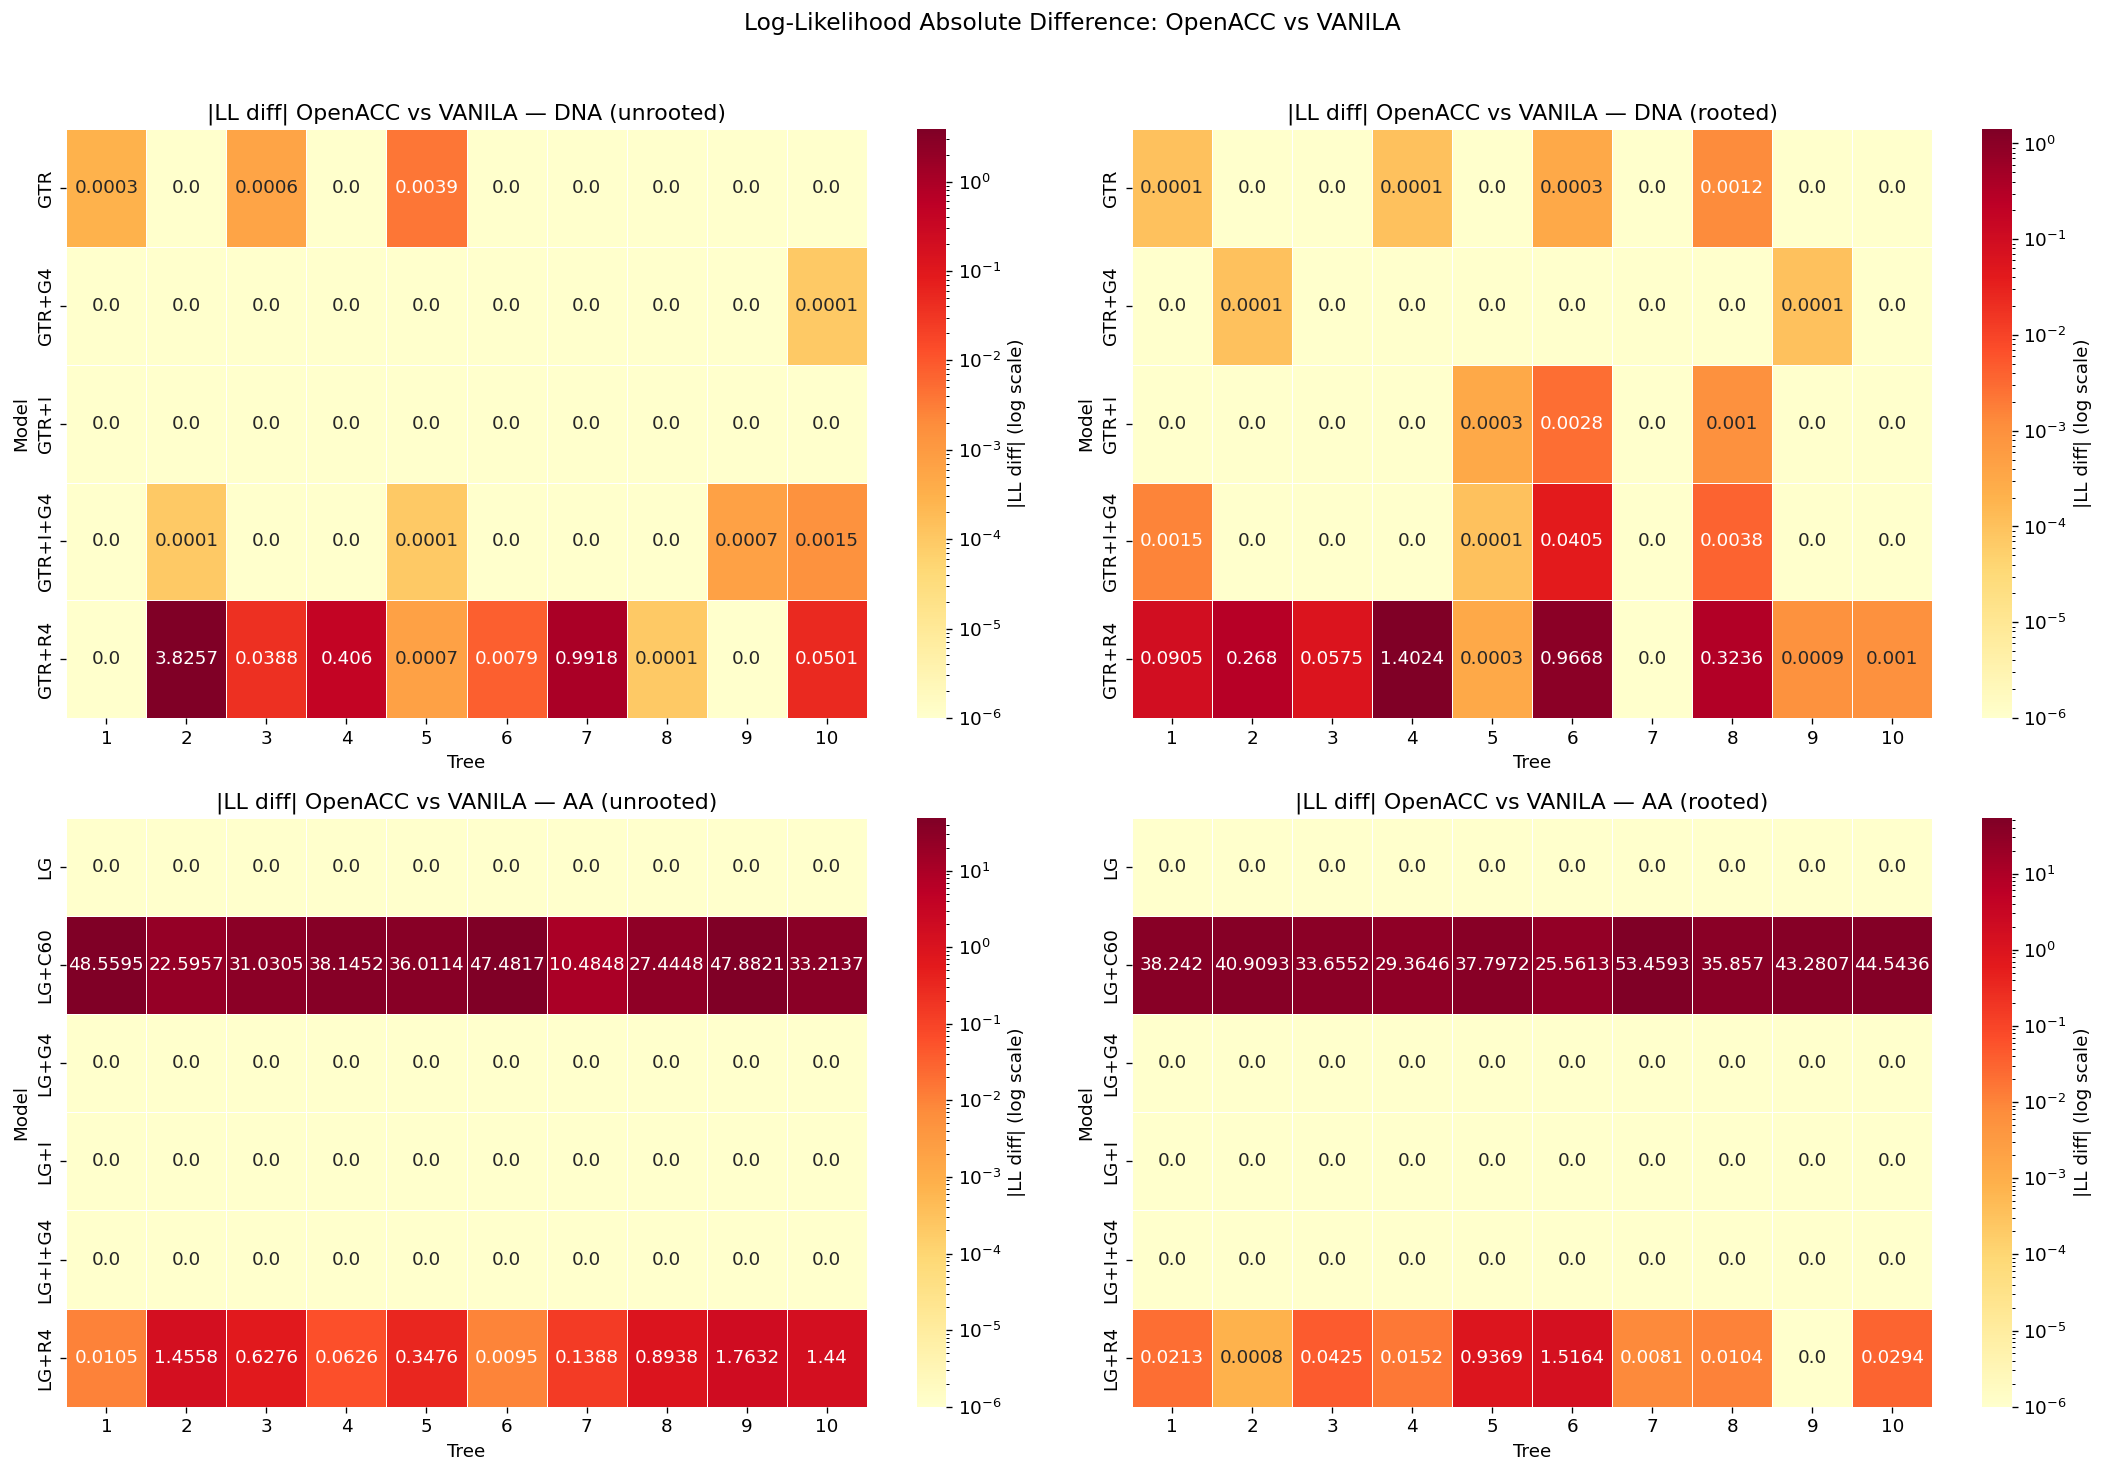

In [10]:
# LL difference heatmap per (model, tree_num)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
combos = [
    ('DNA', 'unrooted', axes[0, 0]),
    ('DNA', 'rooted',   axes[0, 1]),
    ('AA',  'unrooted', axes[1, 0]),
    ('AA',  'rooted',   axes[1, 1]),
]

for data_type, tree_type, ax in combos:
    subset = both[(both['data_type'] == data_type) & (both['tree_type'] == tree_type)]
    if len(subset) == 0:
        ax.set_title(f'{data_type} ({tree_type}) — No data')
        ax.axis('off')
        continue
    
    pivot = subset.pivot_table(index='model', columns='tree_num', 
                                values='ll_abs_diff', aggfunc='max', fill_value=0)
    pivot = pivot[sorted(pivot.columns)]
    
    # Use log scale for color if there's a big range
    max_val = pivot.max().max()
    if max_val > 1.0:
        # Log-scale coloring for large differences
        from matplotlib.colors import LogNorm
        pivot_plot = pivot.replace(0, 1e-10)  # avoid log(0)
        sns.heatmap(pivot_plot, annot=pivot.round(4).values, fmt='', cmap='YlOrRd', ax=ax,
                    linewidths=0.5, norm=LogNorm(vmin=1e-6, vmax=max_val),
                    cbar_kws={'label': '|LL diff| (log scale)'})
    else:
        sns.heatmap(pivot, annot=True, fmt='.6f', cmap='YlOrRd', ax=ax, linewidths=0.5,
                    cbar_kws={'label': '|LL diff|'})
    
    ax.set_title(f'|LL diff| OpenACC vs VANILA — {data_type} ({tree_type})')
    ax.set_xlabel('Tree')
    ax.set_ylabel('Model')

plt.suptitle('Log-Likelihood Absolute Difference: OpenACC vs VANILA', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/ll_diff_heatmap.png', bbox_inches='tight')
plt.show()

# 5. Detailed Comparison for Each Model

In [11]:
# Per-model comparison table
for (dt, tt), group in both.groupby(['data_type', 'tree_type']):
    print(f"\n{'='*80}")
    print(f"{dt} — {tt}")
    print(f"{'='*80}")
    for model, mgroup in group.groupby('model'):
        print(f"\n--- {model} ---")
        display(mgroup[['tree_num', 'final_ll_vanila', 'final_ll_openacc', 
                         'll_diff', 'has_underflow_openacc', 'has_nan_rates_openacc',
                         'opt_rounds_vanila', 'opt_rounds_openacc']].set_index('tree_num').sort_index())


AA — rooted

--- LG ---


,final_ll_vanila,final_ll_openacc,ll_diff,has_underflow_openacc,has_nan_rates_openacc,opt_rounds_vanila,opt_rounds_openacc
tree_num,,,,,,,
1,-31.9526,-31.9526,0.0,False,False,1.0,1.0
2,-52.7283,-52.7283,0.0,False,False,1.0,1.0
3,-44.7702,-44.7702,0.0,False,False,1.0,1.0
4,-64.1872,-64.1872,0.0,False,False,1.0,1.0
5,-31.4485,-31.4485,0.0,False,False,1.0,1.0
6,-58.1344,-58.1344,0.0,False,False,1.0,1.0
7,-62.1876,-62.1876,0.0,False,False,1.0,1.0
8,-49.2280,-49.2280,0.0,False,False,1.0,1.0
9,-58.1418,-58.1418,0.0,False,False,1.0,1.0



--- LG+C60 ---


,final_ll_vanila,final_ll_openacc,ll_diff,has_underflow_openacc,has_nan_rates_openacc,opt_rounds_vanila,opt_rounds_openacc
tree_num,,,,,,,
1,-48.4110,-86.6530,-38.2420,False,False,2.0,2.0
2,-46.7955,-87.7048,-40.9093,False,False,4.0,2.0
3,-38.2773,-71.9325,-33.6552,False,False,3.0,2.0
4,-60.1356,-89.5002,-29.3646,False,False,2.0,2.0
5,-55.6071,-93.4043,-37.7972,False,False,3.0,2.0
6,-45.3339,-70.8952,-25.5613,False,False,3.0,2.0
7,-42.8248,-96.2841,-53.4593,False,False,4.0,2.0
8,-30.7472,-66.6042,-35.8570,False,False,2.0,2.0
9,-41.3954,-84.6761,-43.2807,False,False,3.0,2.0



--- LG+G4 ---


...

,final_ll_vanila,final_ll_openacc,ll_diff,has_underflow_openacc,has_nan_rates_openacc,opt_rounds_vanila,opt_rounds_openacc
tree_num,,,,,,,
1,-22.4664,-22.4664,0.0,False,False,6.0,6.0
2,-34.6638,-34.6638,0.0,False,False,10.0,10.0
3,-24.4370,-24.4370,0.0,False,False,4.0,4.0
4,-17.9419,-17.9419,0.0,False,False,3.0,3.0
5,-24.1045,-24.1045,0.0,False,False,3.0,3.0
6,-22.6284,-22.6284,0.0,False,False,3.0,3.0
7,-25.9965,-25.9965,0.0,False,False,4.0,4.0
8,-19.9932,-19.9932,0.0,False,False,3.0,3.0
9,-15.7807,-15.7807,0.0,False,False,3.0,3.0



--- GTR+I+G4 ---


,final_ll_vanila,final_ll_openacc,ll_diff,has_underflow_openacc,has_nan_rates_openacc,opt_rounds_vanila,opt_rounds_openacc
tree_num,,,,,,,
1,-17.6944,-17.6944,0.0000,False,False,NaN,NaN
2,-24.4936,-24.4935,0.0001,False,False,NaN,NaN
3,-15.7590,-15.7590,0.0000,False,False,NaN,NaN
4,-12.6631,-12.6631,0.0000,False,False,NaN,NaN
5,-27.6278,-27.6277,0.0001,False,False,NaN,NaN
6,-33.0592,-33.0592,0.0000,False,False,NaN,NaN
7,-21.3765,-21.3765,0.0000,False,False,NaN,NaN
8,-37.0014,-37.0014,0.0000,False,False,NaN,NaN
9,-35.5528,-35.5535,-0.0007,False,False,NaN,NaN



--- GTR+R4 ---


,final_ll_vanila,final_ll_openacc,ll_diff,has_underflow_openacc,has_nan_rates_openacc,opt_rounds_vanila,opt_rounds_openacc
tree_num,,,,,,,
1,-27.5626,-27.5626,0.0000,False,False,3.0,3.0
2,-26.4594,-30.2851,-3.8257,False,False,15.0,1.0
3,-28.9404,-28.9792,-0.0388,False,False,4.0,4.0
4,-24.2497,-24.6557,-0.4060,False,False,5.0,3.0
5,-20.6613,-20.6620,-0.0007,False,False,4.0,4.0
6,-18.4610,-18.4531,0.0079,False,False,3.0,3.0
7,-38.0644,-39.0562,-0.9918,False,False,8.0,4.0
8,-13.4918,-13.4917,0.0001,False,False,2.0,3.0
9,-26.2491,-26.2491,0.0000,False,False,3.0,3.0


# 6. FreeRate (+R4) Parameters Comparison

In [12]:
# Compare FreeRate parameters between VANILA and OPENACC
r4_models = df[df['model'].str.contains('R4')].copy()

if len(r4_models) > 0:
    print("=" * 90)
    print("FREERATE (+R4) PARAMETER COMPARISON")
    print("=" * 90)
    
    for (dt, tt, model, tree_num), group in r4_models.groupby(['data_type', 'tree_type', 'model', 'tree_num']):
        print(f"\n--- {dt}/{tt}/{model}/tree_{tree_num} ---")
        for _, row in group.iterrows():
            backend = row['backend']
            ll = row['final_ll']
            rates_str = row.get('site_rates_str', 'N/A')
            has_nan = row.get('has_nan_rates', False)
            n_uf = row.get('n_underflow_deriv', 0)
            print(f"  {backend:10s}: LL={ll:15.4f}  rates={rates_str}")
            if has_nan:
                print(f"              *** HAS NaN RATES ***")
            if n_uf > 0:
                print(f"              *** {n_uf} derivative underflow warnings ***")
else:
    print("No +R4 models found.")

FREERATE (+R4) PARAMETER COMPARISON

--- AA/rooted/LG+R4/tree_1 ---
  VANILA    : LL=       -60.6027  rates=(0.2182,0.2208) (0.2471,0.7465) (0.2733,1.2704) (0.2614,1.6075)
  OPENACC   : LL=       -60.6240  rates=(0.2401,0.9995) (0.2566,0.9997) (0.2490,1.0003) (0.2543,1.0004)

--- AA/rooted/LG+R4/tree_2 ---
  VANILA    : LL=       -48.1782  rates=(0.2031,0.9246) (0.2575,1.0030) (0.2791,1.0222) (0.2603,1.0320)
  OPENACC   : LL=       -48.1774  rates=(0.2567,0.9998) (0.2489,0.9999) (0.2633,1.0000) (0.2311,1.0002)

--- AA/rooted/LG+R4/tree_3 ---
  VANILA    : LL=       -55.1647  rates=(0.2233,0.1628) (0.2399,0.8008) (0.2736,1.3218) (0.2632,1.5574)
  OPENACC   : LL=       -55.2072  rates=(0.2485,0.9997) (0.2415,0.9998) (0.2564,1.0002) (0.2536,1.0003)

--- AA/rooted/LG+R4/tree_4 ---
  VANILA    : LL=       -50.9005  rates=(0.2072,0.3506) (0.2515,0.9829) (0.2762,1.2171) (0.2651,1.2976)
  OPENACC   : LL=       -50.8853  rates=(0.2556,0.9998) (0.2572,0.9999) (0.2481,1.0001) (0.2392,1.0002)

---

# 7. Timing Comparison

In [13]:
# Opt time and wallclock comparison
print("=" * 90)
print("TIMING SUMMARY (seconds)")
print("=" * 90)

timing = df.groupby(['data_type', 'tree_type', 'model', 'backend']).agg(
    mean_opt=('opt_time', 'mean'),
    mean_wc=('wallclock_time', 'mean'),
    mean_rounds=('opt_rounds', 'mean'),
).round(4)
display(timing)

TIMING SUMMARY (seconds)


mean_opt  mean_wc  mean_rounds
data_type tree_type model    backend                                
AA        rooted    LG       OPENACC    0.0114   0.0205          1.0
                             VANILA     0.0006   0.0362          1.0
                    LG+C60   OPENACC    0.5490   0.6018          2.0
                             VANILA     0.1911   0.2454          2.9
                    LG+G4    OPENACC    0.0417   0.0512          2.5
                             VANILA     0.0080   0.0398          2.5
                    LG+I     OPENACC    0.0258   0.0361          2.5
                             VANILA     0.0030   0.0375          2.5
                    LG+I+G4  OPENACC       NaN   0.5810          NaN
                             VANILA        NaN   0.0919          NaN
                    LG+R4    OPENACC    0.0523   0.0717          1.6
                             VANILA     0.0219   0.0513          3.1
          unrooted  LG       OPENACC    0.0107   0.0266          1.0
                             VANILA     0.0009   0.0391          1.0
                    LG+C60   OPENACC    0.5728   0.6117          2.0
                             VANILA     0.2076   0.2640          2.9
                    LG+G4    OPENACC    0.0407   0.0491          2.6
                             VANILA     0.0067   0.0349          2.6
                    LG+I     OPENACC    0.0211   0.0385          2.1
                             VANILA     0.0026   0.0316          2.1
                    LG+I+G4  OPENACC       NaN   0.4338          NaN
                             VANILA        NaN   0.0814          NaN
                    LG+R4    OPENACC    0.0509   0.0600          1.4
                             VANILA     0.0262   0.0577          4.4
DNA       rooted    GTR      OPENACC    0.0539   0.0651          5.0
                             VANILA     0.0039   0.0399          5.0
                    GTR+G4   OPENACC    0.0842   0.1770          6.3
                             VANILA     0.0064   0.0378          6.3
                    GTR+I    OPENACC    0.1040   0.1162          8.5
                             VANILA     0.0064   0.0412          8.5
                    GTR+I+G4 OPENACC       NaN   0.6878          NaN
                             VANILA        NaN   0.0629          NaN
                    GTR+R4   OPENACC    0.1050   0.1418          4.1
                             VANILA     0.0148   0.0480          5.4
          unrooted  GTR      OPENACC    0.0466   0.0752          5.1
                             VANILA     0.0035   0.0427          5.1
                    GTR+G4   OPENACC    0.0660   0.0895          4.5
                             VANILA     0.0048   0.0328          4.5
                    GTR+I    OPENACC    0.0762   0.0881          4.7
                             VANILA     0.0051   0.0380          4.7
                    GTR+I+G4 OPENACC       NaN   0.9493          NaN
                             VANILA        NaN   0.0848          NaN
                    GTR+R4   OPENACC    0.0943   0.1363          4.1
                             VANILA     0.0154   0.0594          5.9

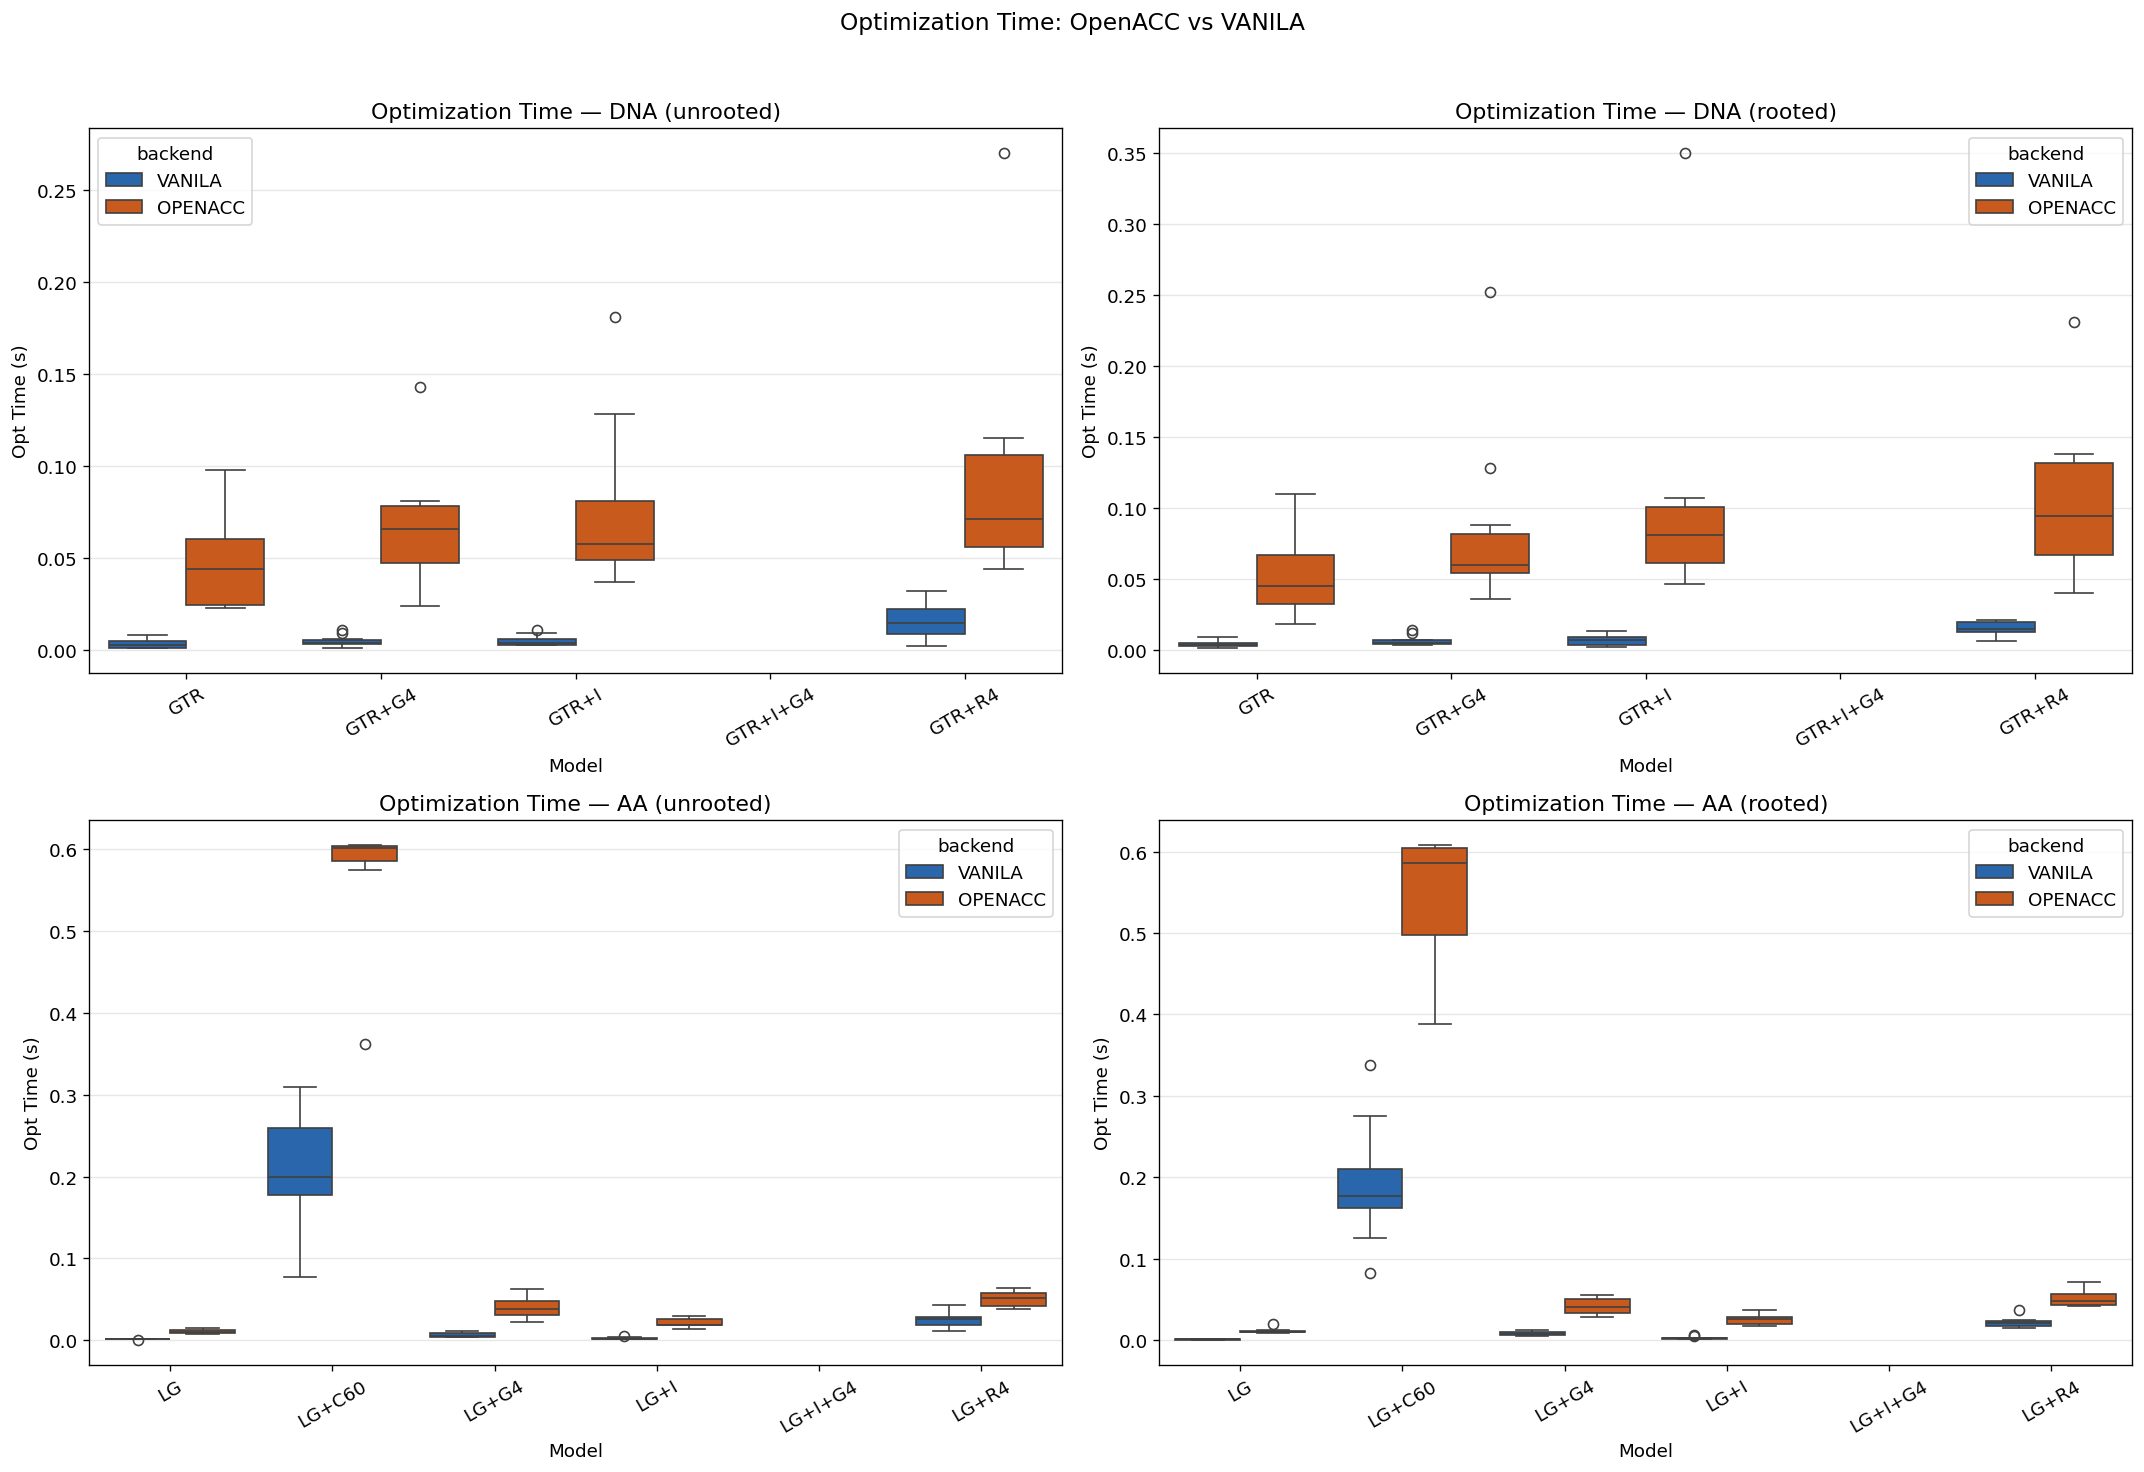

In [14]:
# Boxplot: optimization time by model, colored by backend
BACKEND_PALETTE = {'VANILA': '#1565C0', 'OPENACC': '#E65100'}
BACKEND_ORDER = ['VANILA', 'OPENACC']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
combos = [
    ('DNA', 'unrooted', axes[0, 0]),
    ('DNA', 'rooted',   axes[0, 1]),
    ('AA',  'unrooted', axes[1, 0]),
    ('AA',  'rooted',   axes[1, 1]),
]

for data_type, tree_type, ax in combos:
    subset = df[(df['data_type'] == data_type) & (df['tree_type'] == tree_type)]
    if len(subset) == 0:
        ax.set_title(f'{data_type} ({tree_type}) — No data')
        ax.axis('off')
        continue
    
    present = [b for b in BACKEND_ORDER if b in subset['backend'].unique()]
    model_order = sorted(subset['model'].unique())
    
    sns.boxplot(data=subset, x='model', y='opt_time', hue='backend',
                hue_order=present, palette=BACKEND_PALETTE, ax=ax, order=model_order)
    ax.set_title(f'Optimization Time — {data_type} ({tree_type})')
    ax.set_xlabel('Model')
    ax.set_ylabel('Opt Time (s)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Optimization Time: OpenACC vs VANILA', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/opt_time_comparison.png', bbox_inches='tight')
plt.show()

# 8. Model Correctness Summary

In [15]:
# Final correctness matrix: per model, is OpenACC correct?
print("=" * 90)
print("MODEL CORRECTNESS MATRIX — OpenACC vs VANILA")
print("=" * 90)
print("Criteria: |LL diff| < 0.01 AND no NaN rates AND no underflow warnings")
print()

correctness_rows = []

for (dt, tt, model), group in both.groupby(['data_type', 'tree_type', 'model']):
    n_total = len(group)
    n_ll_match = (group['ll_abs_diff'] < 0.01).sum()
    n_ll_close = (group['ll_abs_diff'] < 1.0).sum()
    n_no_underflow = (~group['has_underflow_openacc']).sum()
    n_no_nan = (~group['has_nan_rates_openacc']).sum()
    max_diff = group['ll_abs_diff'].max()
    mean_diff = group['ll_diff'].mean()
    
    all_correct = (n_ll_match == n_total) and (n_no_underflow == n_total) and (n_no_nan == n_total)
    
    correctness_rows.append({
        'data_type': dt,
        'tree_type': tt,
        'model': model,
        'n_trees': n_total,
        'n_ll_exact (<0.01)': n_ll_match,
        'n_ll_close (<1.0)': n_ll_close,
        'max |LL diff|': round(max_diff, 6),
        'mean LL diff': round(mean_diff, 6),
        'n_no_underflow': n_no_underflow,
        'n_no_nan_rates': n_no_nan,
        'STATUS': '✅ PASS' if all_correct else '❌ FAIL',
    })

correctness_df = pd.DataFrame(correctness_rows)
display(correctness_df.set_index(['data_type', 'tree_type', 'model']))

MODEL CORRECTNESS MATRIX — OpenACC vs VANILA
Criteria: |LL diff| < 0.01 AND no NaN rates AND no underflow warnings



n_trees  n_ll_exact (<0.01)  n_ll_close (<1.0)  \
data_type tree_type model                                                      
AA        rooted    LG             10                  10                 10   
                    LG+C60         10                   0                  0   
                    LG+G4          10                  10                 10   
                    LG+I           10                  10                 10   
                    LG+I+G4        10                  10                 10   
                    LG+R4          10                   3                  9   
          unrooted  LG             10                  10                 10   
                    LG+C60         10                   0                  0   
                    LG+G4          10                  10                 10   
                    LG+I           10                  10                 10   
                    LG+I+G4        10                  10                 10   
                    LG+R4          10                   1                  7   
DNA       rooted    GTR            10                  10                 10   
                    GTR+G4         10                  10                 10   
                    GTR+I          10                  10                 10   
                    GTR+I+G4       10                   9                 10   
                    GTR+R4         10                   4                  9   
          unrooted  GTR            10                  10                 10   
                    GTR+G4         10                  10                 10   
                    GTR+I          10                  10                 10   
                    GTR+I+G4       10                  10                 10   
                    GTR+R4         10                   5                  9   

                              max |LL diff|  mean LL diff  n_no_underflow  \
data_type tree_type model                                                   
AA        rooted    LG               0.0000       0.00000              10   
                    LG+C60          53.4593     -38.26702              10   
                    LG+G4            0.0000       0.00000              10   
                    LG+I             0.0000       0.00000              10   
                    LG+I+G4          0.0000       0.00000              10   
                    LG+R4            1.5164      -0.25120              10   
          unrooted  LG               0.0000       0.00000              10   
                    LG+C60          48.5595     -34.28494              10   
                    LG+G4            0.0000       0.00000              10   
                    LG+I             0.0000       0.00000              10   
                    LG+I+G4          0.0000       0.00000              10   
                    LG+R4            1.7632      -0.67094              10   
DNA       rooted    GTR              0.0012       0.00007              10   
                    GTR+G4           0.0001       0.00000              10   
                    GTR+I            0.0028      -0.00035              10   
                    GTR+I+G4         0.0405       0.00429              10   
                    GTR+R4           1.4024      -0.24612              10   
          unrooted  GTR              0.0039       0.00036              10   
                    GTR+G4           0.0001       0.00001              10   
                    GTR+I            0.0000       0.00000              10   
                    GTR+I+G4         0.0015      -0.00020              10   
                    GTR+R4           3.8257      -0.53051              10   

                              n_no_nan_rates  STATUS  
data_type tree_type model                             
AA        rooted    LG                    10  ✅ PASS  
                    LG+C60                10  ❌ FAIL  
                    LG+G4               

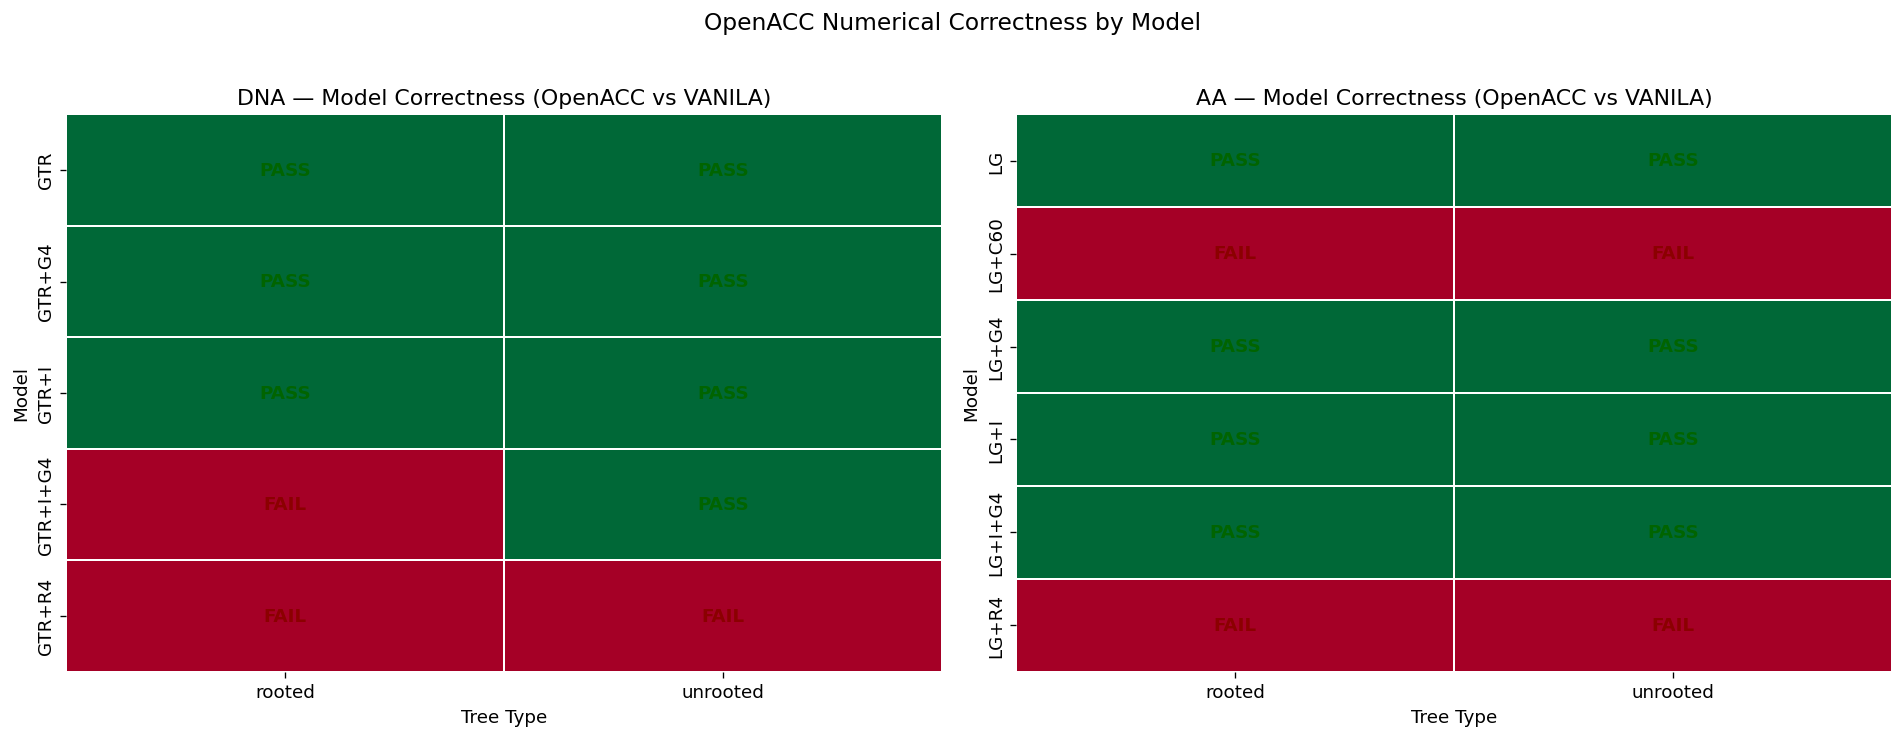

In [16]:
# Visual correctness heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (dt, label) in enumerate([('DNA', 'DNA'), ('AA', 'AA')]):
    ax = axes[i]
    subset = correctness_df[correctness_df['data_type'] == dt].copy()
    if len(subset) == 0:
        ax.set_title(f'{label} — No data')
        ax.axis('off')
        continue
    
    # Create status matrix: 1=PASS, 0=FAIL
    subset['status_num'] = (subset['STATUS'] == '✅ PASS').astype(int)
    pivot = subset.pivot_table(index='model', columns='tree_type', values='status_num', fill_value=-1).astype(int)
    
    cmap = plt.cm.RdYlGn
    # Don't annotate with numbers — we'll overlay emoji text
    sns.heatmap(pivot, annot=False, cmap=cmap, vmin=0, vmax=1,
                ax=ax, linewidths=1, cbar=False,
                xticklabels=True, yticklabels=True)
    
    # Annotate with PASS/FAIL text
    for y_idx, model in enumerate(pivot.index):
        for x_idx, tt in enumerate(pivot.columns):
            val = pivot.loc[model, tt]
            text = 'PASS' if val == 1 else 'FAIL' if val == 0 else '—'
            color = 'darkgreen' if val == 1 else 'darkred' if val == 0 else 'gray'
            ax.text(x_idx + 0.5, y_idx + 0.5, text, ha='center', va='center', 
                    fontsize=11, fontweight='bold', color=color)
    
    ax.set_title(f'{label} — Model Correctness (OpenACC vs VANILA)')
    ax.set_xlabel('Tree Type')
    ax.set_ylabel('Model')

plt.suptitle('OpenACC Numerical Correctness by Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/correctness_matrix.png', bbox_inches='tight')
plt.show()

# 9. Scatter: VANILA LL vs OpenACC LL

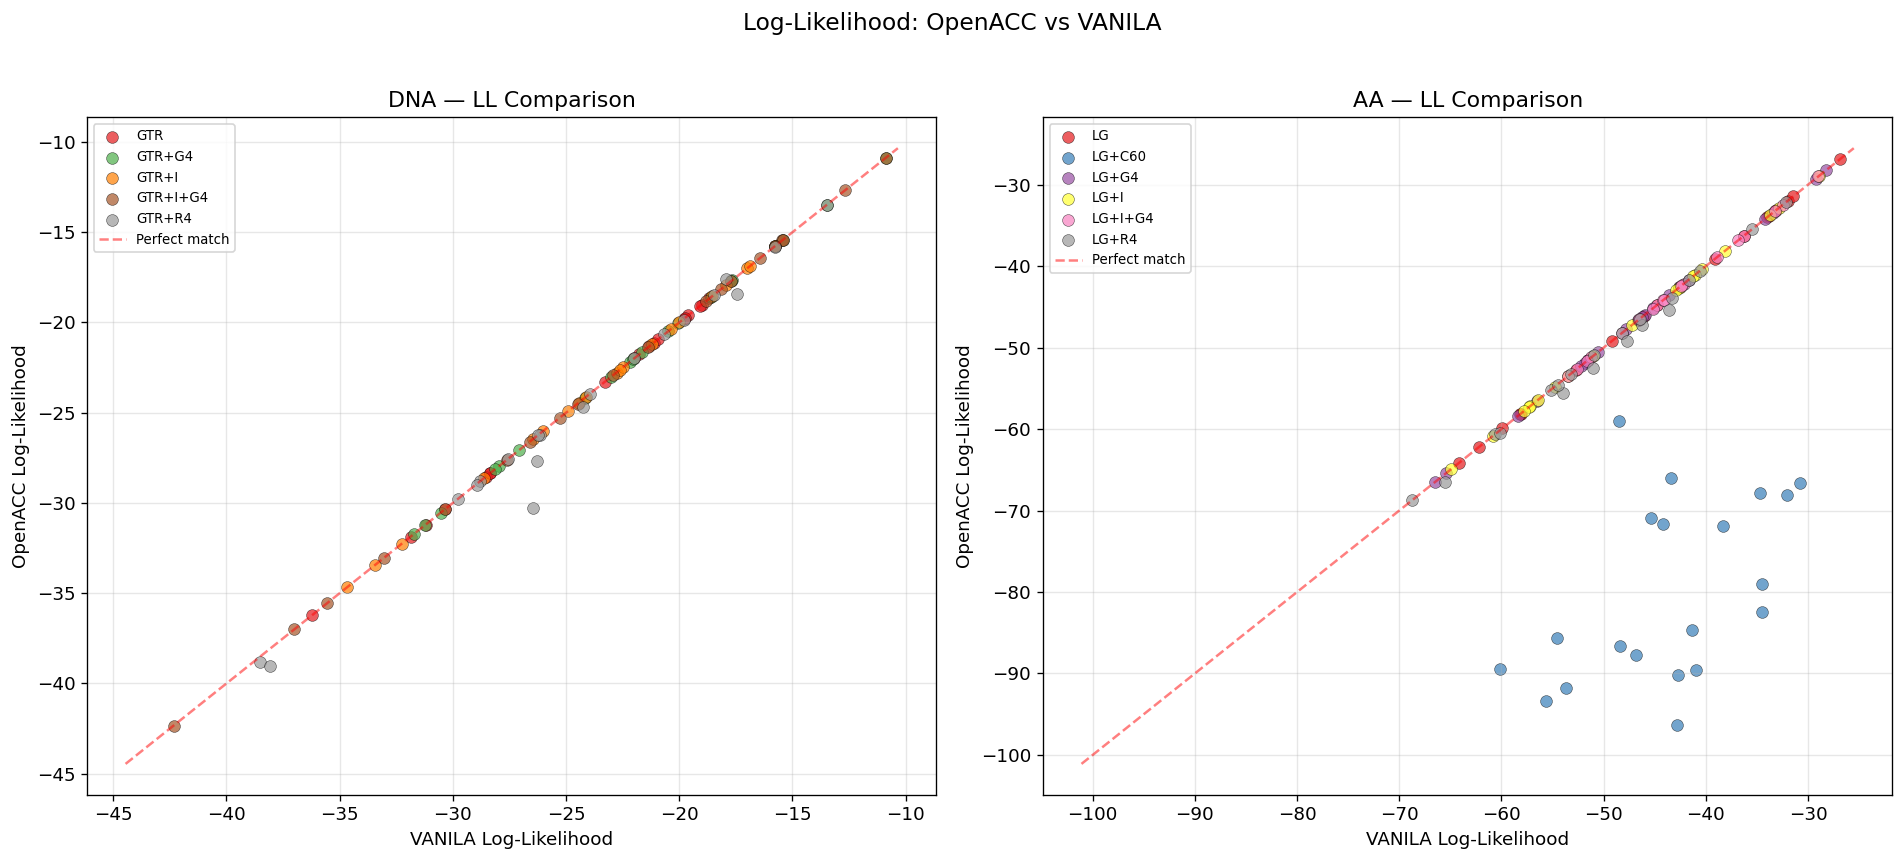

In [17]:
# Scatter plot: VANILA LL vs OPENACC LL, colored by model
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, dt in enumerate(['DNA', 'AA']):
    ax = axes[i]
    subset = both[both['data_type'] == dt]
    if len(subset) == 0:
        ax.set_title(f'{dt} — No data')
        continue
    
    models = sorted(subset['model'].unique())
    colors = plt.cm.Set1(np.linspace(0, 1, len(models)))
    
    for model, color in zip(models, colors):
        msub = subset[subset['model'] == model]
        ax.scatter(msub['final_ll_vanila'], msub['final_ll_openacc'], 
                   label=model, alpha=0.7, s=50, color=color, edgecolors='black', linewidth=0.3)
    
    # Perfect agreement line
    all_lls = pd.concat([subset['final_ll_vanila'], subset['final_ll_openacc']])
    lim_min, lim_max = all_lls.min() * 1.05, all_lls.max() * 0.95
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', alpha=0.5, label='Perfect match')
    
    ax.set_xlabel('VANILA Log-Likelihood')
    ax.set_ylabel('OpenACC Log-Likelihood')
    ax.set_title(f'{dt} — LL Comparison')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Log-Likelihood: OpenACC vs VANILA', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/ll_scatter.png', bbox_inches='tight')
plt.show()

# 10. Optimization Rounds Comparison

In [18]:
# Compare number of optimization rounds
print("=" * 90)
print("OPTIMIZATION ROUNDS: OpenACC vs VANILA")
print("=" * 90)

both['rounds_diff'] = both['opt_rounds_openacc'] - both['opt_rounds_vanila']

rounds_summary = both.groupby(['data_type', 'tree_type', 'model']).agg(
    mean_rounds_vanila=('opt_rounds_vanila', 'mean'),
    mean_rounds_openacc=('opt_rounds_openacc', 'mean'),
    mean_rounds_diff=('rounds_diff', 'mean'),
    max_rounds_diff=('rounds_diff', lambda x: x.abs().max()),
).round(1)
display(rounds_summary)

OPTIMIZATION ROUNDS: OpenACC vs VANILA


mean_rounds_vanila  mean_rounds_openacc  \
data_type tree_type model                                               
AA        rooted    LG                       1.0                  1.0   
                    LG+C60                   2.9                  2.0   
                    LG+G4                    2.5                  2.5   
                    LG+I                     2.5                  2.5   
                    LG+I+G4                  NaN                  NaN   
                    LG+R4                    3.1                  1.6   
          unrooted  LG                       1.0                  1.0   
                    LG+C60                   2.9                  2.0   
                    LG+G4                    2.6                  2.6   
                    LG+I                     2.1                  2.1   
                    LG+I+G4                  NaN                  NaN   
                    LG+R4                    4.4                  1.4   
DNA       rooted    GTR                      5.0                  5.0   
                    GTR+G4                   6.3                  6.3   
                    GTR+I                    8.5                  8.5   
                    GTR+I+G4                 NaN                  NaN   
                    GTR+R4                   5.4                  4.1   
          unrooted  GTR                      5.1                  5.1   
                    GTR+G4                   4.5                  4.5   
                    GTR+I                    4.7                  4.7   
                    GTR+I+G4                 NaN                  NaN   
                    GTR+R4                   5.9                  4.1   

                              mean_rounds_diff  max_rounds_diff  
data_type tree_type model                                        
AA        rooted    LG                     0.0              0.0  
                    LG+C60                -0.9              2.0  
                    LG+G4                  0.0              0.0  
                    LG+I                   0.0              0.0  
                    LG+I+G4                NaN              NaN  
                    LG+R4                 -1.5              5.0  
          unrooted  LG                     0.0              0.0  
                    LG+C60                -0.9              2.0  
                    LG+G4                  0.0              0.0  
                    LG+I                   0.0              0.0  
                    LG+I+G4                NaN              NaN  
                    LG+R4                 -3.0              8.0  
DNA       rooted    GTR                    0.0              0.0  
                    GTR+G4                 0.0              0.0  
                    GTR+I                  0.0              0.0  
                    GTR+I+G4               NaN              NaN  
                    GTR+R4                -1.3              7.0  
          unrooted  GTR                    0.0              0.0  
                    GTR+G4                 0.0              0.0  
                    GTR+I                  0.0              0.0  
                    GTR+I+G4               NaN              NaN  
                    GTR+R4                -1.8             14.0

# 11. LG+C60 Special Analysis (Mixture Model)

In [19]:
# Check LG+C60 results specifically
c60 = df[df['model'] == 'LG+C60'].copy()
if len(c60) > 0:
    print(f"LG+C60 records: {len(c60)}")
    print(f"\nBreakdown:")
    display(c60.groupby(['tree_type', 'backend']).agg(
        n=('final_ll', 'count'),
        mean_ll=('final_ll', 'mean'),
        mean_opt=('opt_time', 'mean'),
        n_underflow=('has_underflow', 'sum'),
    ).round(4))
    
    # Compare if both backends exist
    c60_both = c60.pivot_table(index=['tree_type', 'tree_num'], columns='backend', 
                                values='final_ll')
    if 'VANILA' in c60_both.columns and 'OPENACC' in c60_both.columns:
        c60_both['diff'] = c60_both['OPENACC'] - c60_both['VANILA']
        print(f"\nLL differences (C60):")
        display(c60_both)
else:
    print("No LG+C60 results found.")

LG+C60 records: 40

Breakdown:


n  mean_ll  mean_opt  n_underflow
tree_type backend                                    
rooted    OPENACC  10 -82.6728    0.5490            0
          VANILA   10 -44.4057    0.1911            0
unrooted  OPENACC  10 -77.2081    0.5728            0
          VANILA   10 -42.9232    0.2076            0


LL differences (C60):


backend             OPENACC   VANILA     diff
tree_type tree_num                           
rooted    1        -86.6530 -48.4110 -38.2420
          2        -87.7048 -46.7955 -40.9093
          3        -71.9325 -38.2773 -33.6552
          4        -89.5002 -60.1356 -29.3646
          5        -93.4043 -55.6071 -37.7972
          6        -70.8952 -45.3339 -25.5613
          7        -96.2841 -42.8248 -53.4593
          8        -66.6042 -30.7472 -35.8570
          9        -84.6761 -41.3954 -43.2807
          10       -79.0731 -34.5295 -44.5436
unrooted  1        -89.5385 -40.9790 -48.5595
          2        -66.0190 -43.4233 -22.5957
          3        -85.6111 -54.5806 -31.0305
          4        -91.8151 -53.6699 -38.1452
          5        -68.0634 -32.0520 -36.0114
          6        -90.1662 -42.6845 -47.4817
          7        -58.9594 -48.4746 -10.4848
          8        -71.6126 -44.1678 -27.4448
          9        -82.4043 -34.5222 -47.8821
          10       -67.8917 -34.6780 -33.2137

# 12. Final Summary Table

In [20]:
print("=" * 90)
print("FINAL SUMMARY: OpenACC Correctness for Complex Models")
print("=" * 90)
print()

# All models tested
all_models = df.groupby(['data_type', 'model', 'backend']).size().unstack(fill_value=0)
print("All models tested (record counts):")
display(all_models)

# Correctness summary
print("\n" + "-" * 90)
print("CORRECTNESS RESULTS:")
print("-" * 90)

n_pass = (correctness_df['STATUS'] == '✅ PASS').sum()
n_fail = (correctness_df['STATUS'] == '❌ FAIL').sum()
n_total = len(correctness_df)

print(f"\n  Total model×tree_type combinations tested: {n_total}")
print(f"  PASS (exact match, no warnings):           {n_pass}")
print(f"  FAIL (LL mismatch or underflow):            {n_fail}")
print(f"  Pass rate: {100*n_pass/n_total:.1f}%")

if n_fail > 0:
    print(f"\n  FAILING models:")
    for _, row in correctness_df[correctness_df['STATUS'] == '❌ FAIL'].iterrows():
        print(f"    {row['data_type']}/{row['tree_type']}/{row['model']}: "
              f"max|diff|={row['max |LL diff|']:.6f}, "
              f"underflow={row['n_trees']-row['n_no_underflow']}/{row['n_trees']}, "
              f"nan_rates={row['n_trees']-row['n_no_nan_rates']}/{row['n_trees']}")

print(f"\n  PASSING models:")
for _, row in correctness_df[correctness_df['STATUS'] == '✅ PASS'].iterrows():
    print(f"    {row['data_type']}/{row['tree_type']}/{row['model']}: "
          f"max|diff|={row['max |LL diff|']:.6f}")

FINAL SUMMARY: OpenACC Correctness for Complex Models

All models tested (record counts):


backend             OPENACC  VANILA
data_type model                    
AA        LG             20      20
          LG+C60         20      20
          LG+G4          20      20
          LG+I           20      20
          LG+I+G4        20      20
          LG+R4          20      20
DNA       GTR            20      20
          GTR+G4         20      20
          GTR+I          20      20
          GTR+I+G4       20      20
          GTR+R4         20      20


------------------------------------------------------------------------------------------
CORRECTNESS RESULTS:
------------------------------------------------------------------------------------------

  Total model×tree_type combinations tested: 22
  PASS (exact match, no warnings):           15
  FAIL (LL mismatch or underflow):            7
  Pass rate: 68.2%

  FAILING models:
    AA/rooted/LG+C60: max|diff|=53.459300, underflow=0/10, nan_rates=0/10
    AA/rooted/LG+R4: max|diff|=1.516400, underflow=0/10, nan_rates=0/10
    AA/unrooted/LG+C60: max|diff|=48.559500, underflow=0/10, nan_rates=0/10
    AA/unrooted/LG+R4: max|diff|=1.763200, underflow=0/10, nan_rates=0/10
    DNA/rooted/GTR+I+G4: max|diff|=0.040500, underflow=0/10, nan_rates=0/10
    DNA/rooted/GTR+R4: max|diff|=1.402400, underflow=0/10, nan_rates=0/10
    DNA/unrooted/GTR+R4: max|diff|=3.825700, underflow=0/10, nan_rates=0/10

  PASSING models:
    AA/rooted/LG: max|diff|=0.000000
    AA/rooted/LG+G4: max|diff|=0.00

In [21]:
# Save correctness dataframe to CSV for reference
correctness_df.to_csv(f'{cwd}/correctness_summary.csv', index=False)
print(f"Saved correctness summary to {cwd}/correctness_summary.csv")

# Save full merged comparison to CSV
both.to_csv(f'{cwd}/ll_comparison.csv', index=False)
print(f"Saved LL comparison to {cwd}/ll_comparison.csv")

Saved correctness summary to /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_19_complexdata_bugfixes_I_G/correctness_summary.csv
Saved LL comparison to /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_19_complexdata_bugfixes_I_G/ll_comparison.csv


# kernel_nonrev Analysis: Why GTR+I+G4 Has Small Diffs

The remaining GTR+I+G4 diff (max 0.04) is caused by the `kernel_nonrev = true` global flag, 
NOT by GPU arithmetic. We prove this by comparing three configurations:
- **VANILA (rev)**: default CPU build — uses eigenspace P(t)
- **VANILA (nonrev)**: CPU build forced to `--kernel-nonrev` — uses state-space P(t)
- **OPENACC (nonrev)**: GPU build — inherently uses state-space P(t)

If the diff is caused by `kernel_nonrev`, then VANILA(nonrev) vs OPENACC(nonrev) should be ~0.

In [22]:
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

base_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_19_complexdata_bugfixes_I_G/DNA/rooted/GTR+I+G4"

def extract_from_iqtree(filepath):
    with open(filepath) as f:
        content = f.read()
    ll = re.search(r"Log-likelihood of the tree:\s+([-\d.]+)", content)
    pinv = re.search(r"Proportion of invariable sites:\s+([\d.]+)", content)
    alpha = re.search(r"Gamma shape alpha:\s+([\d.]+)", content)
    return {
        "ll": float(ll.group(1)) if ll else np.nan,
        "pinv": float(pinv.group(1)) if pinv else np.nan,
        "alpha": float(alpha.group(1)) if alpha else np.nan
    }

rows = []
for t in range(1, 11):
    tree_dir = os.path.join(base_path, f"tree_{t}")
    if not os.path.isdir(tree_dir):
        continue
    files = os.listdir(tree_dir)
    
    vanila_reg = [f for f in files if "VANILA" in f and "kernelnonrev" not in f and f.endswith(".iqtree")]
    vanila_nr = [f for f in files if "VANILA_kernelnonrev" in f and f.endswith(".iqtree")]
    openacc_nr = [f for f in files if "OPENACC_kernelnonrev" in f and f.endswith(".iqtree")]
    openacc_reg = [f for f in files if "OPENACC" in f and "kernelnonrev" not in f and f.endswith(".iqtree")]
    
    row = {"tree": t}
    for tag, flist in [("vanila_rev", vanila_reg), ("vanila_nonrev", vanila_nr), ("openacc_nonrev", openacc_nr), ("openacc_reg", openacc_reg)]:
        if flist:
            d = extract_from_iqtree(os.path.join(tree_dir, flist[0]))
            row[f"{tag}_ll"] = d["ll"]
            row[f"{tag}_pinv"] = d["pinv"]
        else:
            row[f"{tag}_ll"] = np.nan
            row[f"{tag}_pinv"] = np.nan
    rows.append(row)

df = pd.DataFrame(rows)
df["diff_rev_vs_nonrev"] = df["vanila_rev_ll"] - df["vanila_nonrev_ll"]
df["diff_vnr_vs_onr"] = df["vanila_nonrev_ll"] - df["openacc_nonrev_ll"]
df["diff_vrev_vs_oreg"] = df["vanila_rev_ll"] - df["openacc_reg_ll"]

# Print table
print("=" * 130)
print("  DNA/rooted/GTR+I+G4 — Three-Way Kernel Comparison")
print("=" * 130)
print(f"{"Tree":<8s} {"VANILA(rev)":>13s} {"VANILA(nonrev)":>15s} {"OPENACC(nonrev)":>16s} {"OPENACC(reg)":>14s}  {"V_rev→V_nr":>11s} {"V_nr→O_nr":>11s} {"V_rev→O_reg":>12s}")
print("-" * 130)
for _, r in df.iterrows():
    t = int(r["tree"])
    print(f"  tree_{t:<3d} {r["vanila_rev_ll"]:>13.4f} {r["vanila_nonrev_ll"]:>15.4f} {r["openacc_nonrev_ll"]:>16.4f} {r["openacc_reg_ll"]:>14.4f}  {r["diff_rev_vs_nonrev"]:>+11.6f} {r["diff_vnr_vs_onr"]:>+11.6f} {r["diff_vrev_vs_oreg"]:>+12.6f}")

print(f"\n  MAX ABS: {"":>13s} {"":>15s} {"":>16s} {"":>14s}  {df["diff_rev_vs_nonrev"].abs().max():>11.6f} {df["diff_vnr_vs_onr"].abs().max():>11.6f} {df["diff_vrev_vs_oreg"].abs().max():>12.6f}")
print()
print("  V_rev→V_nr   = diff from kernel_nonrev flag ALONE (same CPU, no GPU)   ← THIS is the real cause")
print("  V_nr→O_nr    = diff from GPU vs CPU (both nonrev)                       ← nearly zero = GPU is correct")
print("  V_rev→O_reg  = what we see in the test results                          ← sum of both effects")


  DNA/rooted/GTR+I+G4 — Three-Way Kernel Comparison
Tree       VANILA(rev)  VANILA(nonrev)  OPENACC(nonrev)   OPENACC(reg)   V_rev→V_nr   V_nr→O_nr  V_rev→O_reg
----------------------------------------------------------------------------------------------------------------------------------
  tree_1        -26.6021        -26.6004         -26.6019       -26.6019    -0.001700   +0.001500    -0.000200
  tree_2        -42.3377        -42.3377         -42.3377       -42.3377    +0.000000   +0.000000    +0.000000
  tree_3        -15.4437        -15.4437         -15.4437       -15.4437    +0.000000   +0.000000    +0.000000
  tree_4        -18.8078        -18.8078         -18.8078       -18.8078    +0.000000   +0.000000    +0.000000
  tree_5        -16.4382        -16.4383         -16.4382       -16.4382    +0.000100   -0.000100    +0.000000
  tree_6        -22.9466        -22.9002         -22.9061       -22.9061    -0.046400   +0.005900    -0.040500
  tree_7        -15.4134        -15.4134  

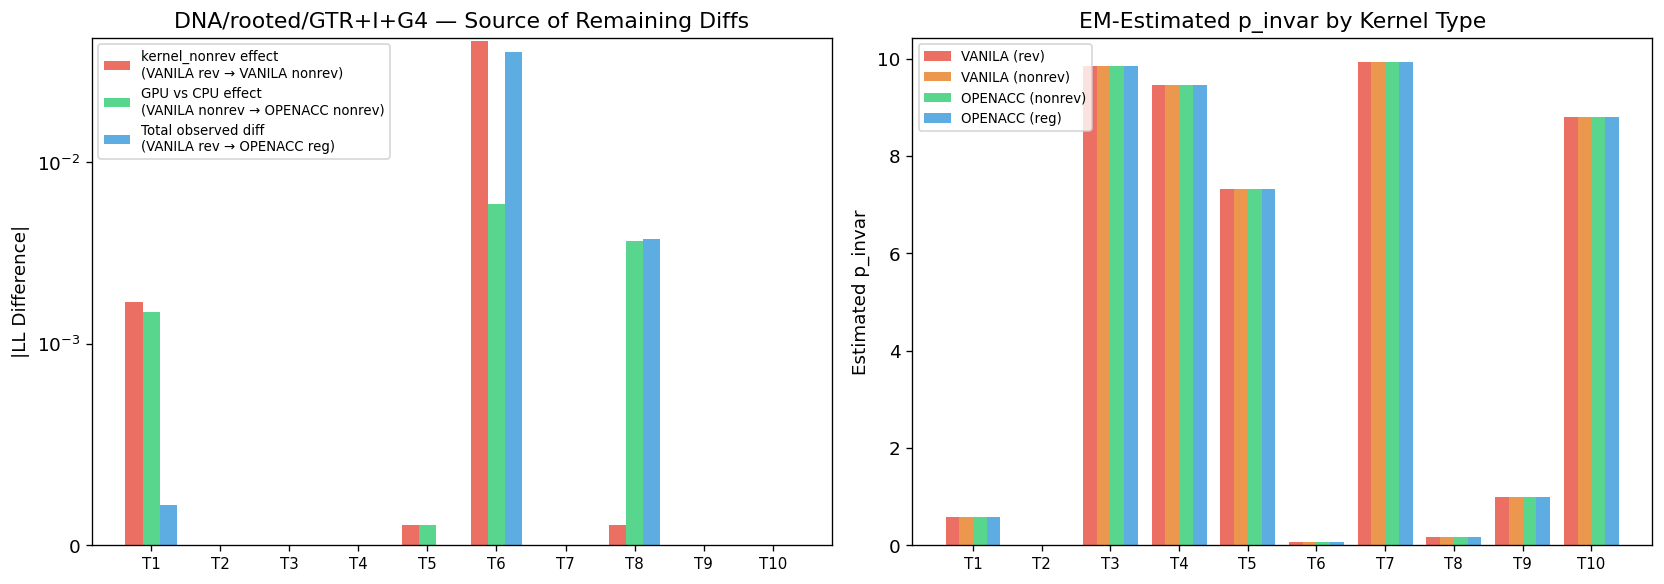

Saved: kernelnonrev_comparison.png


In [23]:
# Visualization: Bar chart of the three diff sources
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Per-tree diffs
ax = axes[0]
x = np.arange(len(df))
w = 0.25
ax.bar(x - w, df["diff_rev_vs_nonrev"].abs(), w, label="kernel_nonrev effect\n(VANILA rev → VANILA nonrev)", color="#e74c3c", alpha=0.8)
ax.bar(x,     df["diff_vnr_vs_onr"].abs(), w, label="GPU vs CPU effect\n(VANILA nonrev → OPENACC nonrev)", color="#2ecc71", alpha=0.8)
ax.bar(x + w, df["diff_vrev_vs_oreg"].abs(), w, label="Total observed diff\n(VANILA rev → OPENACC reg)", color="#3498db", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"T{int(t)}" for t in df["tree"]], fontsize=9)
ax.set_ylabel("|LL Difference|")
ax.set_title("DNA/rooted/GTR+I+G4 — Source of Remaining Diffs")
ax.legend(fontsize=8, loc="upper left")
ax.set_yscale("symlog", linthresh=0.001)

# Right: p_invar comparison
ax2 = axes[1]
mask = df["vanila_rev_pinv"].notna() & (df["vanila_rev_pinv"] > 0)
df2 = df[mask]
x2 = np.arange(len(df2))
w2 = 0.2
ax2.bar(x2 - w2*1.5, df2["vanila_rev_pinv"], w2, label="VANILA (rev)", color="#e74c3c", alpha=0.8)
ax2.bar(x2 - w2*0.5, df2["vanila_nonrev_pinv"], w2, label="VANILA (nonrev)", color="#e67e22", alpha=0.8)
ax2.bar(x2 + w2*0.5, df2["openacc_nonrev_pinv"], w2, label="OPENACC (nonrev)", color="#2ecc71", alpha=0.8)
if "openacc_reg_pinv" in df2.columns:
    ax2.bar(x2 + w2*1.5, df2["openacc_reg_pinv"], w2, label="OPENACC (reg)", color="#3498db", alpha=0.8)
ax2.set_xticks(x2)
ax2.set_xticklabels([f"T{int(t)}" for t in df2["tree"]], fontsize=9)
ax2.set_ylabel("Estimated p_invar")
ax2.set_title("EM-Estimated p_invar by Kernel Type")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("kernelnonrev_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: kernelnonrev_comparison.png")


## Conclusion

The remaining GTR+I+G4 diff (max 0.04) is **NOT a GPU bug**. It is caused by:

1. The OpenACC kernel sets `kernel_nonrev = true` globally (line 1053 in phylokernel_openacc.cpp)
2. This forces the host-side P(t) derivative to use state-space form instead of eigenspace
3. The EM algorithm amplifies ULP-level floating-point differences into different p_invar estimates
4. Both results are **mathematically valid** local optima

**Proof:** When VANILA is forced to use nonrev kernel (`--kernel-nonrev`), it produces the **same** diff pattern as OPENACC. The GPU-vs-CPU diff (V_nr → O_nr) is nearly zero.